In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import pycwt as wavelet
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import sys
import seaborn as sns
from pathlib import Path
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.stats import zscore


# Add project root to path
project_root = project_root = Path(r'C:\Users\walimunige.rupasingh\OneDrive - University of Calgary\Documents\GitHub\ENSO_effects_SD')
sys.path.append(str(project_root))

In [2]:
# Configuration
config = {   
    'SWEI_nino_data_8mo': project_root / 'data' / 'output_data' / 'ENSO_SWEI'/'SWEI_nino_data_8mo.csv',
    'SWEI_nino_data_1mo': project_root / 'data' / 'output_data' / 'ENSO_SWEI'/'SWEI_nino_data_1mo.csv',
    'ENSO_input_data': project_root / 'data' / 'input_data' / 'nina34.anom.csv',
    'output_dir': project_root / 'data' / 'output_data'/'LAG_ENSO_SWEI',
    'plots_dir': project_root / 'data' / 'output_plots'/'LAG_ENSO_SWEI'
}

In [3]:
# Load SWEI and ENSO data
swei_8mo = pd.read_csv(config['SWEI_nino_data_8mo'])
swei_1mo = pd.read_csv(config['SWEI_nino_data_1mo'])
enso_data = pd.read_csv(config['ENSO_input_data'])

display(swei_8mo.head())
display(swei_1mo.head())
display(enso_data.head())

,Elevation_Category,Seasonal_Year,SWEI,ENSO
0,1000_1500m,1980,-0.8,-0.4
1,1000_1500m,1981,0.3,-0.0
2,1000_1500m,1982,-0.9,1.7
3,1000_1500m,1983,-0.4,-0.8
4,1000_1500m,1984,-0.1,-1.0


,Elevation_Category,Seasonal_Year,month,SWEI,ENSO,Year,Month
0,1000_1500m,1980,1,-1.573456,-0.36,1981,1
1,1000_1500m,1980,2,-0.754661,-0.64,1981,2
2,1000_1500m,1980,3,-1.294272,-0.64,1981,3
3,1000_1500m,1980,4,-0.979583,-0.53,1981,4
4,1000_1500m,1980,5,1.227319,-0.57,1981,5


,Date,Nino Anom 3.4 Index using ersstv5 from CPC missing value -99.99 https://psl.noaa.gov/data/timeseries/month/
0,1948-01-01,-9999.0
1,1948-02-01,-9999.0
2,1948-03-01,-9999.0
3,1948-04-01,-9999.0
4,1948-05-01,-9999.0


# Wavelet Coherence

In [4]:
# Convert time column to datetime
enso_data["Date"] = pd.to_datetime(enso_data["Date"])

# select data from 1980-2024
enso_data = enso_data[(enso_data["Date"].dt.year >= 1980) & (enso_data["Date"].dt.year <= 2024)].copy()

enso_data["Year"] = enso_data["Date"].dt.year
enso_data["Month"] = enso_data["Date"].dt.month


In [5]:
def calculate_seasonal_enso(
    enso_data: pd.DataFrame,
    months: list,
    season_name: str,
    year_col: str = "Year",
    month_col: str = "Month"
) -> pd.DataFrame:
    """
    Calculate seasonal mean Niño anomaly.

    Parameters
    ----------
    enso_data : pd.DataFrame
        ENSO dataframe containing Year, Month and Niño anomaly columns.
    months : list
        Months to average (e.g., [6,7,8] for JJA).
    season_name : str
        Name of the season (e.g., 'JJA', 'SON', 'DJF').
    year_col : str
        Name of year column.
    month_col : str
        Name of month column.

    Returns
    -------
    pd.DataFrame
        Columns:
            Seasonal_Year
            ENSO_<season_name>
    """

    # Automatically find the Niño anomaly column
    nino_col = next(
        col for col in enso_data.columns
        if "nino" in col.lower() and "anom" in col.lower()
    )

    seasonal_enso = (
        enso_data.loc[enso_data[month_col].isin(months)]
        .groupby(year_col, as_index=False)
        .agg(**{f"ENSO_{season_name}": (nino_col, "mean")})
        .rename(columns={year_col: "Seasonal_Year"})
    )

    return seasonal_enso

def merge_seasonal_enso(
    swei_data: pd.DataFrame,
    seasonal_enso: pd.DataFrame,
    enso_col: str,
    year_col: str = "Seasonal_Year",
    how: str = "inner"
) -> pd.DataFrame:
    """
    Merge a seasonal ENSO index with the SWEI dataset.

    Parameters
    ----------
    swei_data : pd.DataFrame
        SWEI dataframe containing Seasonal_Year.
    seasonal_enso : pd.DataFrame
        Seasonal ENSO dataframe returned by calculate_seasonal_enso().
    enso_col : str
        Name of the ENSO column to merge
        (e.g., 'ENSO_JJA', 'ENSO_SON').
    year_col : str, optional
        Name of the year column (default='Seasonal_Year').
    how : str, optional
        Merge method ('inner', 'left', etc.).

    Returns
    -------
    pd.DataFrame
        SWEI dataframe with the seasonal ENSO column added.
    """

    merged = (
        swei_data
        .drop(columns=[enso_col], errors="ignore")
        .merge(
            seasonal_enso[[year_col, enso_col]],
            on=year_col,
            how=how
        )
    )

    return merged

In [7]:
elevations = [
    '500_1000m',
    '1000_1500m',
    '1500_2000m',
    '2000_2500m'
]

for elev in elevations:
    # Build yearly ENSO-SWEI dataset once and then subset by elevation
    seasonal_enso = calculate_seasonal_enso(
        enso_data=enso_data,
        months=[9,10,11],   # SON
        season_name="JJA"
    )

    lagged_data = merge_seasonal_enso(
        swei_data=swei_8mo.copy(),
        seasonal_enso=seasonal_enso,
        enso_col="ENSO_JJA",
        year_col="Seasonal_Year",
        how="inner"
    )

    subset_elev = (
        lagged_data[lagged_data["Elevation_Category"] == elev]
        .sort_values("Seasonal_Year")
        .copy()
    )
    
    x = subset_elev['ENSO_JJA'].values
    y = subset_elev['SWEI'].values
    
    dt = 1
    
    WCT, aWCT, coi, freq, sig = wavelet.wct(x, y, dt)
    
    print(f"Elevation: {elev}")
    print(f"WCT shape: {WCT.shape}")
    print(f"aWCT shape: {aWCT.shape}")

NOTE: WCT significance loaded from cache.

Elevation: 500_1000m
WCT shape: (55, 44)
aWCT shape: (55, 44)
NOTE: WCT significance loaded from cache.

Elevation: 1000_1500m
WCT shape: (55, 44)
aWCT shape: (55, 44)
NOTE: WCT significance loaded from cache.

Elevation: 1500_2000m
WCT shape: (55, 44)
aWCT shape: (55, 44)
NOTE: WCT significance loaded from cache.

Elevation: 2000_2500m
WCT shape: (55, 44)
aWCT shape: (55, 44)


c:\Users\walimunige.rupasingh\OneDrive - University of Calgary\Documents\GitHub\ENSO_effects_SD\.venv\Lib\site-packages\pycwt\wavelet.py:633: RuntimeWarning: invalid value encountered in arctanh
  aa = numpy.round(numpy.arctanh(numpy.array([al1, al2]) * 4))
c:\Users\walimunige.rupasingh\OneDrive - University of Calgary\Documents\GitHub\ENSO_effects_SD\.venv\Lib\site-packages\pycwt\wavelet.py:633: RuntimeWarning: invalid value encountered in arctanh
  aa = numpy.round(numpy.arctanh(numpy.array([al1, al2]) * 4))


c:\Users\walimunige.rupasingh\OneDrive - University of Calgary\Documents\GitHub\ENSO_effects_SD\.venv\Lib\site-packages\pycwt\wavelet.py:633: RuntimeWarning: invalid value encountered in arctanh
  aa = numpy.round(numpy.arctanh(numpy.array([al1, al2]) * 4))
C:\Users\walimunige.rupasingh\AppData\Local\Temp\ipykernel_50712\1935019516.py:56: UserWarning: The following kwargs were not used by contour: 'linestyle'
  ax.contour(
C:\Users\walimunige.rupasingh\AppData\Local\Temp\ipykernel_50712\1935019516.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.arange(1980, 2025, 5).astype(int), fontsize=16, fontweight='bold')
C:\Users\walimunige.rupasingh\AppData\Local\Temp\ipykernel_50712\1935019516.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{int(2**p)}" for p in ax.get_yticks(

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.

NOTE: WCT significance loaded from cache.



C:\Users\walimunige.rupasingh\AppData\Local\Temp\ipykernel_50712\1935019516.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


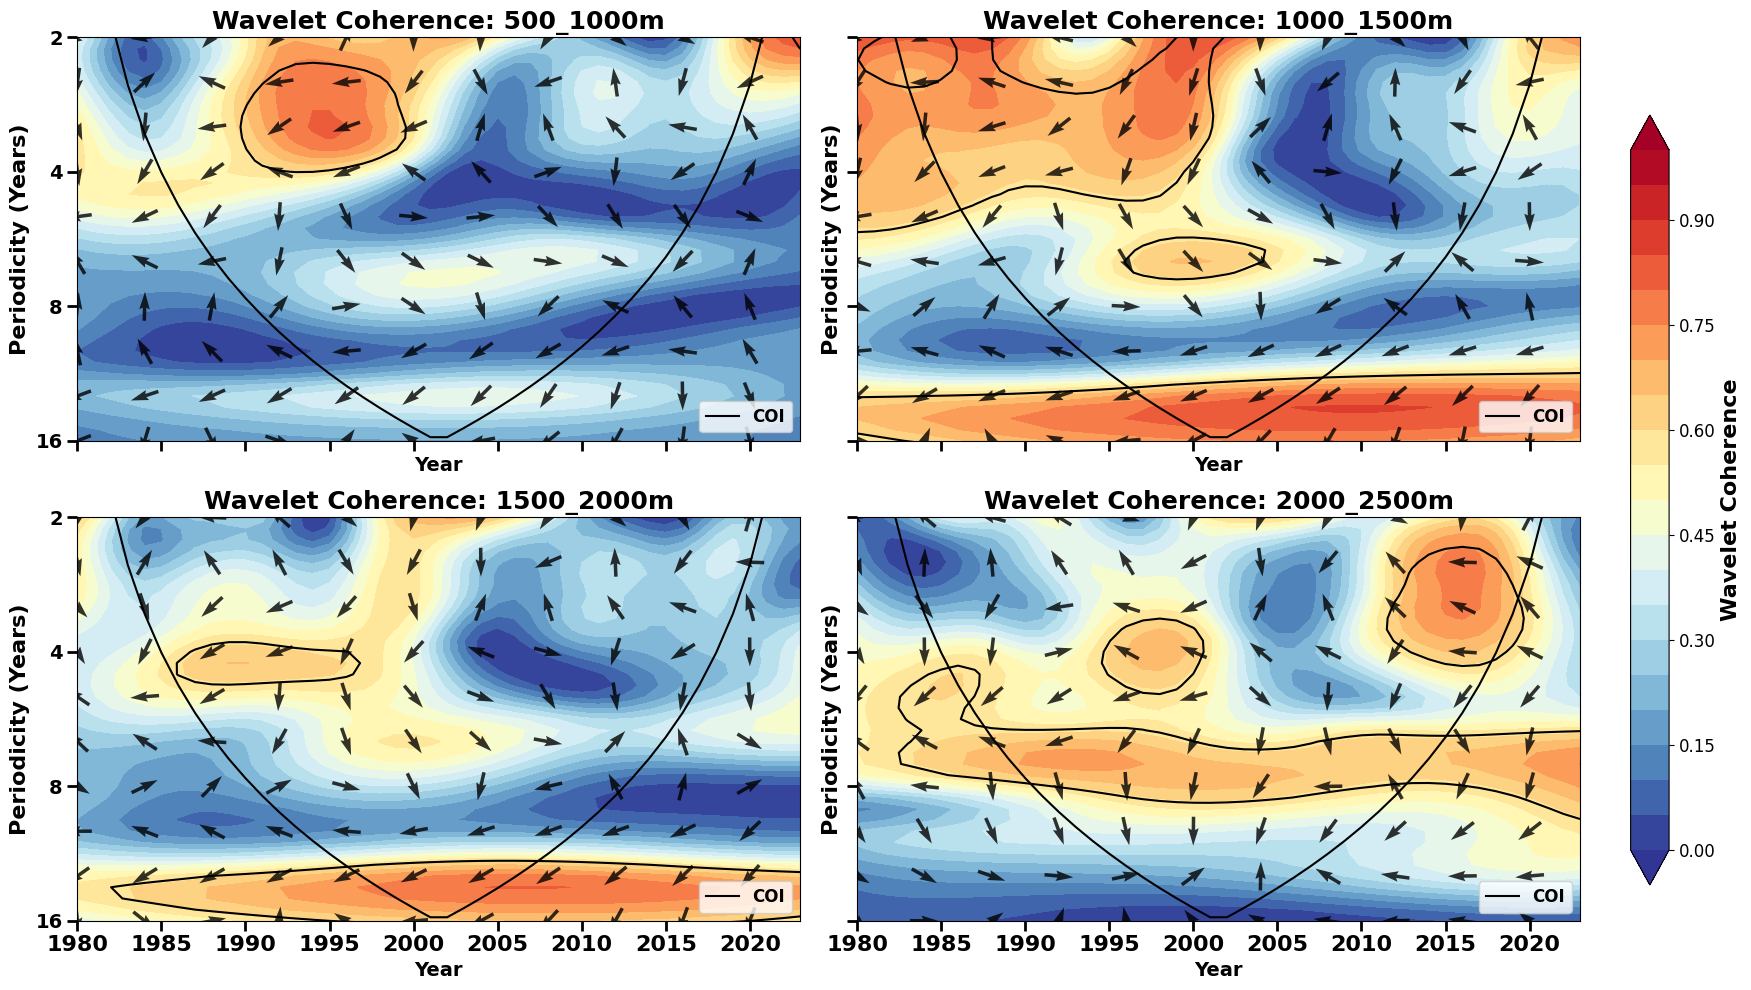

In [8]:
# Run wavelet coherence
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)

for i, elev in enumerate(elevations):
    ax = axes.flat[i]

    subset_elev = lagged_data[lagged_data['Elevation_Category'] == elev].copy()
    subset_elev = subset_elev.sort_values('Seasonal_Year')

    x = subset_elev['ENSO_JJA'].values
    y = subset_elev['SWEI'].values
    t = subset_elev['Seasonal_Year'].values
    dt = 1

    WCT, aWCT, coi, freq, sig = wavelet.wct(x, y, dt)
    period = 1 / freq

    cf = ax.contourf(
        t,
        np.log2(period),
        WCT,
        levels=np.linspace(0, 1, 21),
        cmap='RdYlBu_r',
        extend='both'
    )

    # phase arrows
    skip = 4

    Y, X = np.meshgrid(np.log2(period), t)

    phase = aWCT.T

    u = np.cos(phase)
    v = np.sin(phase)

    ax.quiver(
        X[::skip, ::skip],
        Y[::skip, ::skip],
        u[::skip, ::skip],
        v[::skip, ::skip],
        units='width',
        angles='uv',
        pivot='mid',
        scale=25,
        color='black',
        alpha=0.8
    )

    # significance contour
    sig95 = np.tile(sig[:, None], (1, len(t)))
    sig95 = WCT / sig95
    # expand 1D sig to 2D to match (period x time) grid
    sig2d = np.tile(sig[:, None], (1, t.size))

    ax.contour(
        t,
        np.log2(period),
        sig95,
        levels=[1],
        colors='black',
        linestyle='--',
        linewidths=1.5
    )

    ax.plot(t, np.log2(coi), color='black', linewidth=1.5, label='COI')
    ax.set_title(f'Wavelet Coherence: {elev}', fontsize=18, fontweight='bold')
    ax.set_xlabel('Year', fontsize=14, fontweight='bold')
    ax.set_xticklabels(np.arange(1980, 2025, 5).astype(int), fontsize=16, fontweight='bold')
    ax.tick_params(axis='x', which='major', width=2, length=7)
    ax.set_ylabel('Periodicity (Years)', fontsize=16, fontweight='bold')
    ax.set_yticklabels([f"{int(2**p)}" for p in ax.get_yticks()], fontsize=16, fontweight='bold')
    period_ticks = np.array([2, 4, 8, 16])
    ax.set_yticks(np.log2(period_ticks))
    ax.tick_params(axis='y', which='major', width=2, length=7)
    ax.set_yticklabels(period_ticks, fontsize=14, fontweight='bold')
    ax.set_ylim(np.log2(16), np.log2(2))
    legend = ax.legend(loc='lower right', fontsize=12, frameon=True)
    for txt in legend.get_texts():
        txt.set_fontweight('bold')
        txt.set_fontweight('bold')

fig.subplots_adjust(right=1.05)
cbar = fig.colorbar(cf, ax=axes.ravel().tolist(), location='right', pad=0.02, fraction=0.03)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Wavelet Coherence', fontsize=16, fontweight='bold')
plt.savefig(config['plots_dir'] / 'wavelet_coherence_SWEI_ENSO_lag_SON.png', dpi=1000, bbox_inches='tight')
plt.tight_layout()
plt.show()